In [10]:
#Считайте данные из файлов, сохраните их в переменные соответствующие переменные

import pandas as pd

df_p = pd.read_csv("Products.csv", sep=';') # для Products
df_c = pd.read_csv("Customers.csv", sep=';') # для Customers
df_o = pd.read_csv("Orders.csv", sep=';')  # для Orders
df_od = pd.read_csv("Order_details.csv", sep=';') # для Order_details
df_e = pd.read_excel("Employees.xlsx") # для Employees

In [ ]:
#по данным из файла Orders

Постройте гистограмму для столбца EmployeeID. Сотрудник с каким ID оформил больше всего заказов за все время? # EmployeeID 4

4


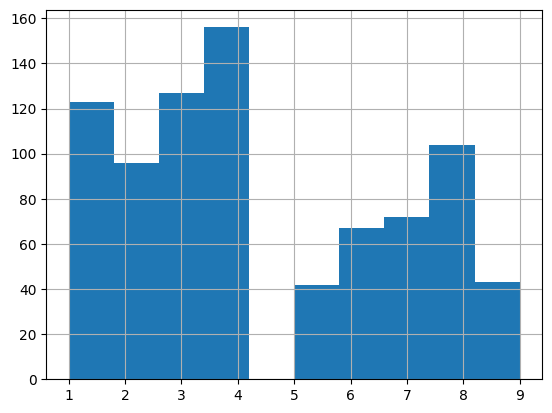

In [14]:
df_o['EmployeeID'].hist()
print(df_o['EmployeeID'].value_counts().idxmax())

In [ ]:
#по данным из файла Orders и Order_details

Посчитайте отдельно по 1997 и по 1998 году чистую выручку в разрезе недель. Запишите результаты в новые датафреймы.
Далее объедините их в общий датафрейм, в котором будет 3 столбца: номер недели, чистая выручка 1997 год, чистая выручка 1998 год.
Постройте столбчатую диаграмму и выберите номера недель, на которых выручка в 1997 году была выше чем в 1998. #1 и 17

Примечание: Объедините датафреймы с помощью типа соединения inner, чтобы в итоговый датафрейм попали только недели, по которым есть заказы и в 1997 и в 1998 году.

[1, 17]


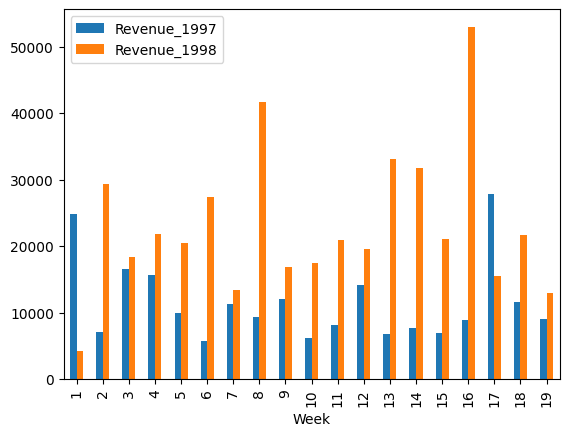

In [6]:
df_od['NetRevenue'] = df_od['UnitPrice'] * df_od['Quantity'] * (1 - df_od['Discount'])
df_o['OrderDate'] = pd.to_datetime(df_o['OrderDate'])
df_o['Week'] = df_o['OrderDate'].dt.isocalendar().week
df_o_1997 = df_o[df_o['OrderDate'].dt.year == 1997]
df_o_1998 = df_o[df_o['OrderDate'].dt.year == 1998]
rev_1997 = df_o_1997.merge(df_od, on='OrderID').groupby('Week', as_index=False)['NetRevenue'].sum().rename(columns={'NetRevenue': 'Revenue_1997'})
rev_1998 = df_o_1998.merge(df_od, on='OrderID').groupby('Week', as_index=False)['NetRevenue'].sum().rename(columns={'NetRevenue': 'Revenue_1998'})
rev_comparison = rev_1997.merge(rev_1998, on='Week', how='inner')
rev_comparison.plot(x='Week', y=['Revenue_1997', 'Revenue_1998'], kind='bar')
print(rev_comparison[rev_comparison['Revenue_1997'] > rev_comparison['Revenue_1998']]['Week'].tolist())

In [ ]:
#по данным из файла Order_details

Посчитайте фактическую скидку и чистую выручку для каждой строки в датафрейме df_od.
Затем сгруппируйте чистую выручку и фактическую скидку для каждого заказа. Далее постройте scatter plot, где по вертикали расположится фактическая скидка, а по горизонтали - чистая выручка.

Примечание: Вы можете оставить только заказы со скидкой перед построением scatter plot.

<Axes: xlabel='NetRevenue', ylabel='ActualDiscount'>

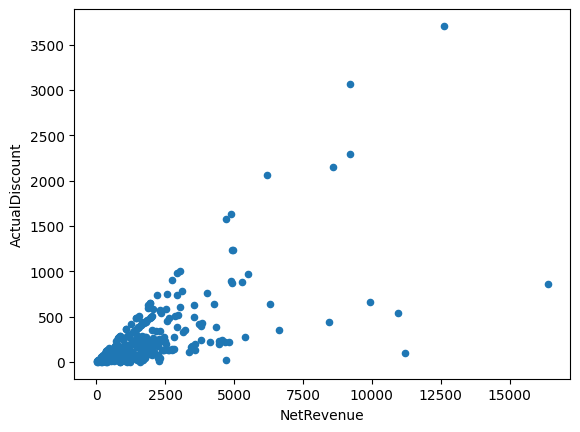

In [7]:
df_od['NetRevenue'] = df_od['UnitPrice'] * df_od['Quantity'] * (1 - df_od['Discount'])
df_od['ActualDiscount'] = df_od['UnitPrice'] * df_od['Quantity'] * df_od['Discount']
order_summary = df_od.groupby('OrderID', as_index=False).agg({'NetRevenue': 'sum', 'ActualDiscount': 'sum'})
order_summary = order_summary[order_summary['ActualDiscount'] > 0]
order_summary.plot.scatter(x='NetRevenue', y='ActualDiscount')

In [ ]:
#по данным из файла Orders

Постройте гистограмму распределения веса товара (столбец Freight)
Проведите поиск выбросов методом IQR
Обозначьте на гистограмме границы квартилей и границы выбросов
Постройте два boxplot-а, отобразив на одном из них полный набор данных, а на втором - без выбросов.

Q1: 13.379999999999999, Q3: 91.43, Lower Bound: -103.69500000000002, Upper Bound: 208.50500000000002


<Axes: >

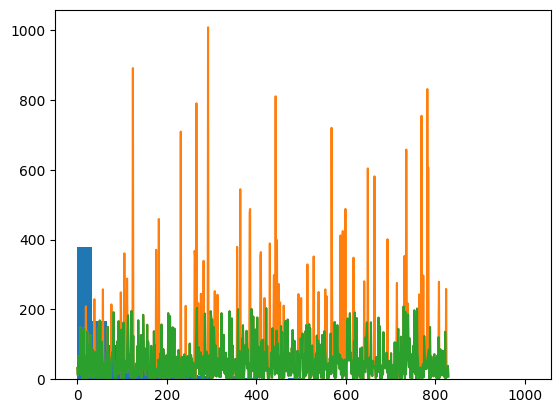

In [ ]:
df_o['Freight'].hist(bins=30)
Q1 = df_o['Freight'].quantile(0.25)
Q3 = df_o['Freight'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#df_o['Freight'].hist(bins=30)
print(f"Q1: {Q1}, Q3: {Q3}, Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
df_o['Freight'].plot()
df_o_no_outliers = df_o[(df_o['Freight'] >= lower_bound) & (df_o['Freight'] <= upper_bound)]
df_o_no_outliers['Freight'].plot()


**Задачи со случайным набором данных**

In [ ]:
Задание 1:

1. Сгенерировать два массива данных для осей X и Y.
2. Построить график, где ось X будет представлять значения времени, а ось Y - значения некоторой величины (например, температуры, скорости и т.д. с формулой произвольной сложности).
3. На графике отразить данные красной линией и синими точками.
4. Добавить название графика, подписи к осям.
5. Сохранить график в файл с расширением PNG.

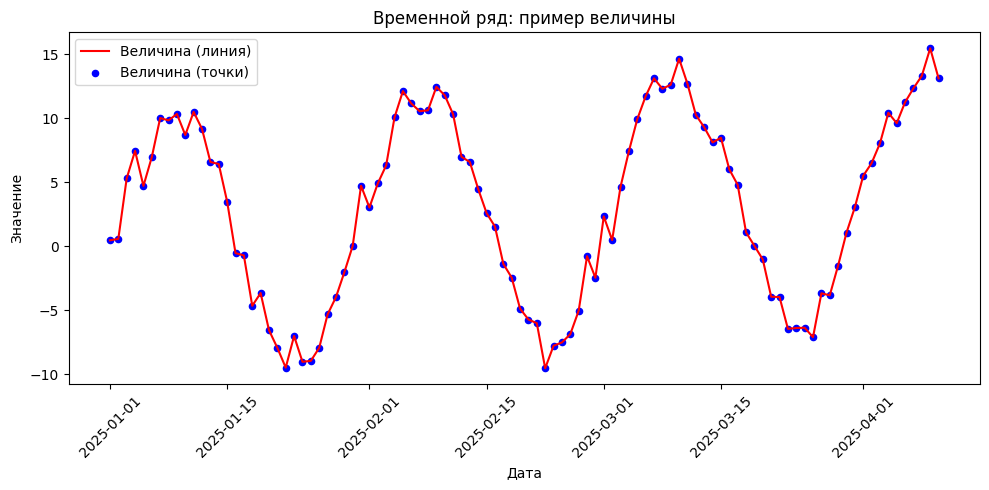

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = 100
dates = pd.date_range(start='2025-01-01', periods=n, freq='D')
t = np.arange(n)

rng = np.random.default_rng(42)
y = 10 * np.sin(2 * np.pi * t / 30) + 0.05 * t + rng.normal(0, 1.5, size=n)

plt.figure(figsize=(10, 5))
plt.plot(dates, y, color='red', linewidth=1.5, label='Величина (линия)')
plt.scatter(dates, y, color='blue', s=20, label='Величина (точки)')
plt.title('Временной ряд: пример величины')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task1_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
Задание 2:

1. Сгенерировать массив значений X для построения графиков.
2. Построить четыре графика на одной фигуре, каждый из которых будет отображать одну из четырех элементарных тригонометрических функций: синус, косинус, тангенс и котангенс.
3. Каждый график должен быть размещен в своем отдельном подграфике.
4. Задать подписи для каждого графика, название фигуры и названия подграфиков, а также подписи осей.
5. Сохранить график в файл с расширением PNG.

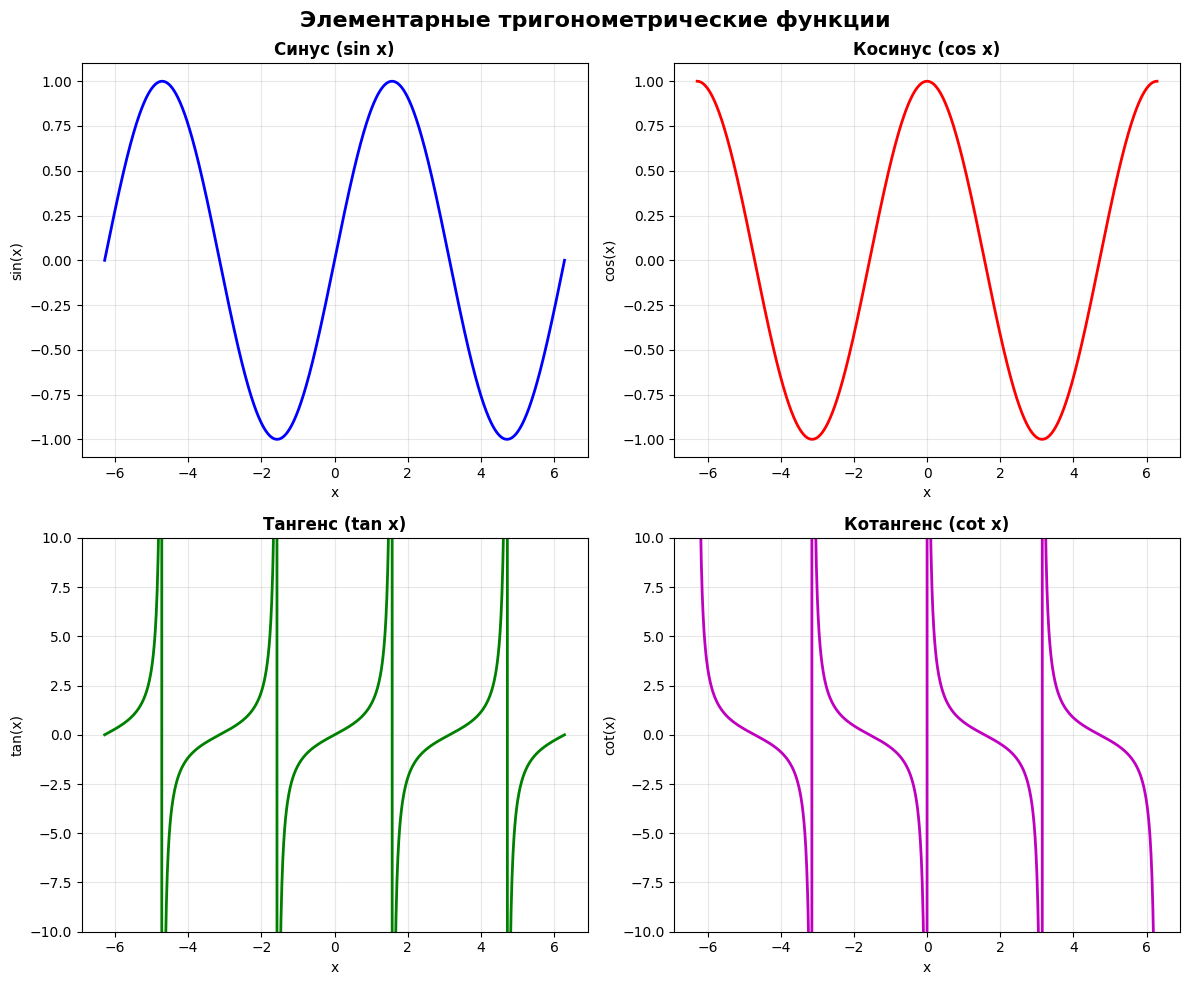

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2*np.pi, 2*np.pi, 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Элементарные тригонометрические функции', fontsize=16, fontweight='bold')

axes[0, 0].plot(x, np.sin(x), 'b-', linewidth=2)
axes[0, 0].set_title('Синус (sin x)', fontweight='bold')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('sin(x)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x, np.cos(x), 'r-', linewidth=2)
axes[0, 1].set_title('Косинус (cos x)', fontweight='bold')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('cos(x)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(x, np.tan(x), 'g-', linewidth=2)
axes[1, 0].set_title('Тангенс (tan x)', fontweight='bold')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('tan(x)')
axes[1, 0].set_ylim(-10, 10)
axes[1, 0].grid(True, alpha=0.3)


axes[1, 1].plot(x, 1/np.tan(x), 'm-', linewidth=2)
axes[1, 1].set_title('Котангенс (cot x)', fontweight='bold')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('cot(x)')
axes[1, 1].set_ylim(-10, 10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trigonometric_functions.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
Задание3 :

1. Сгенерируйте 100 случайных точек для координат X и Y. Используйте функцию numpy.random для генерации чисел с плавающей запятой в диапазоне от 0 до 100.
2. Постройте график рассеяния, используя полученные координаты X и Y.
3. Добавьте заголовок графика и подписи для осей X и Y.
4. Измените цвет и размер маркеров в зависимости от значений по оси Y, чтобы визуально выделить точки.
5. Включите легенду, чтобы объяснить, что представляют собой используемые цвета и размеры маркеров.
6. Сохраните получившийся график в файл формата PNG.

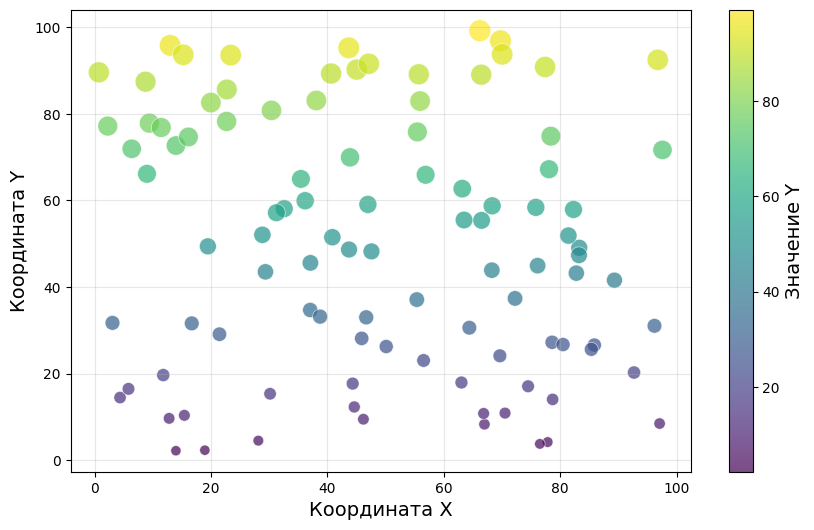

In [13]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
x = rng.uniform(0, 100, 100)
y = rng.uniform(0, 100, 100)
colors = y
sizes = 50 + (y / 100) * 200
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x, y, c=colors, s=sizes, cmap='viridis', alpha=0.7, edgecolors='w', linewidth=0.5)
plt.xlabel('Координата X', fontsize=14)
plt.ylabel('Координата Y', fontsize=14)         
cbar = plt.colorbar(scatter)
cbar.set_label('Значение Y', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
Задание 4:

Построить поверхности для x[–2,2] и y[–2,2], изменяя значения с шагом 0,5 для функций:
1) z = x**2–2*y**2
2) x**2+ y**2 + z**2 = 4**2

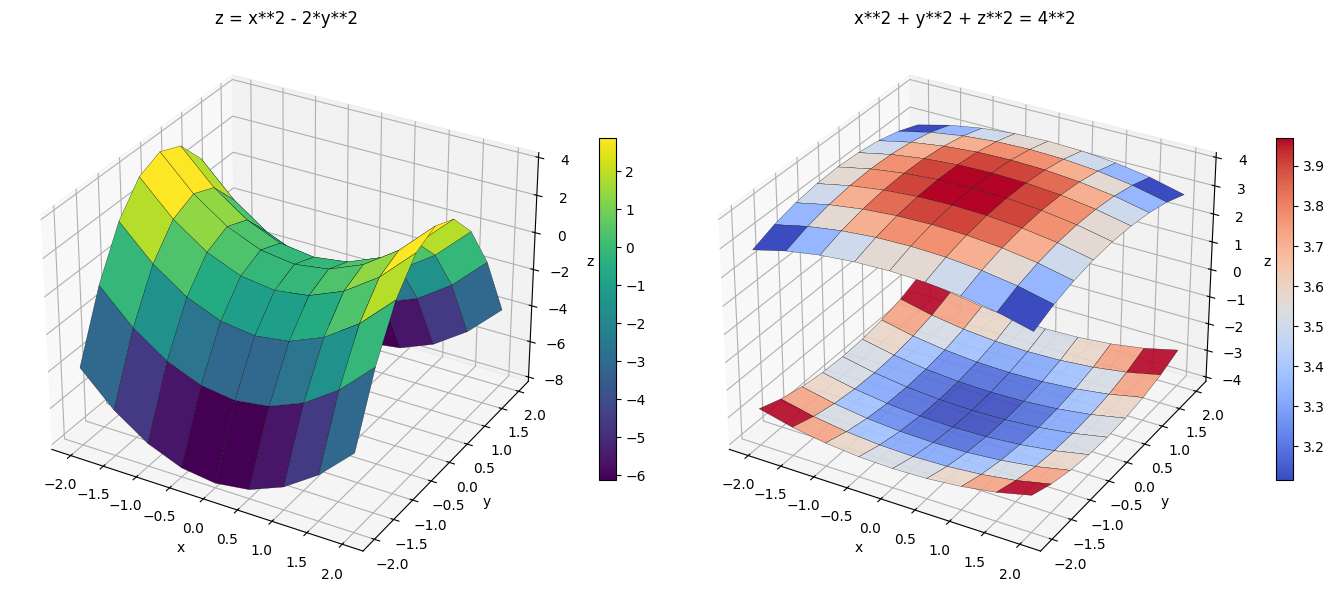

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-2, 2.5, 0.5)
y = np.arange(-2, 2.5, 0.5)
X, Y = np.meshgrid(x, y)

Z1 = X**2 - 2 * Y**2

R2 = 16
inside = X**2 + Y**2 <= R2
Z2_pos = np.where(inside, np.sqrt(R2 - X**2 - Y**2), np.nan)
Z2_neg = np.where(inside, -np.sqrt(R2 - X**2 - Y**2), np.nan)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z1, cmap='viridis', edgecolor='k', linewidth=0.2, antialiased=True)
ax1.set_title('z = x**2 - 2*y**2')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
fig.colorbar(surf1, ax=ax1, shrink=0.6)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2p = ax2.plot_surface(X, Y, Z2_pos, cmap='coolwarm', edgecolor='k', linewidth=0.2, antialiased=True)
surf2n = ax2.plot_surface(X, Y, Z2_neg, cmap='coolwarm', edgecolor='k', linewidth=0.2, antialiased=True, alpha=0.9)
ax2.set_title('x**2 + y**2 + z**2 = 4**2')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
fig.colorbar(surf2p, ax=ax2, shrink=0.6)

plt.tight_layout()
plt.savefig('task4_surfaces.png', dpi=200, bbox_inches='tight')
plt.show()